In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
warnings.simplefilter("ignore", pd.errors.DtypeWarning)

# Plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Helper functions
from helper_functions import (
    load_signal_data,
    extract_operating_periods,
    extract_steady_states_from_windows,
    test_dbscan_eps,
    make_window_features,
    clean_signals,
    extract_steady_states_by_threshold,
    get_signal_df,
    _window_mean,
    build_model_window_df
)

In [2]:
search_folder = "step_interpolation_10s/G2_relevant"

dfs = load_signal_data(search_folder)
cleaned_dfs, invalid_summary = clean_signals(dfs)

In [3]:
power_name = "Generator active power"
field_current_name = "Exciter current"
pos_name = "Total needle opening position"
inletp_name = "Turbine inlet pressure"
vib_name = "DE Vibration"
speed_name = "Rotational speed"
setpoint_name = "Set point"

speed = get_signal_df(dfs, speed_name)
power = get_signal_df(dfs, power_name)
vib = get_signal_df(dfs, vib_name)
field_current = get_signal_df(dfs, field_current_name)
pos = get_signal_df(dfs, pos_name)
inletp = get_signal_df(dfs, inletp_name)
setpoint = get_signal_df(dfs, setpoint_name)

In [4]:
operating_periods = extract_operating_periods(
    speed_df=speed,
    power_df=power,
    speed_threshold=90,
    power_threshold=0.5,
    min_samples=30
)

In [5]:
pelt_df = pd.read_csv("pelt_times.csv")
pelt_df["Datetime"] = pd.to_datetime(pelt_df["Datetime"])

pelt_times = pelt_df["Datetime"].dropna().sort_values().tolist()

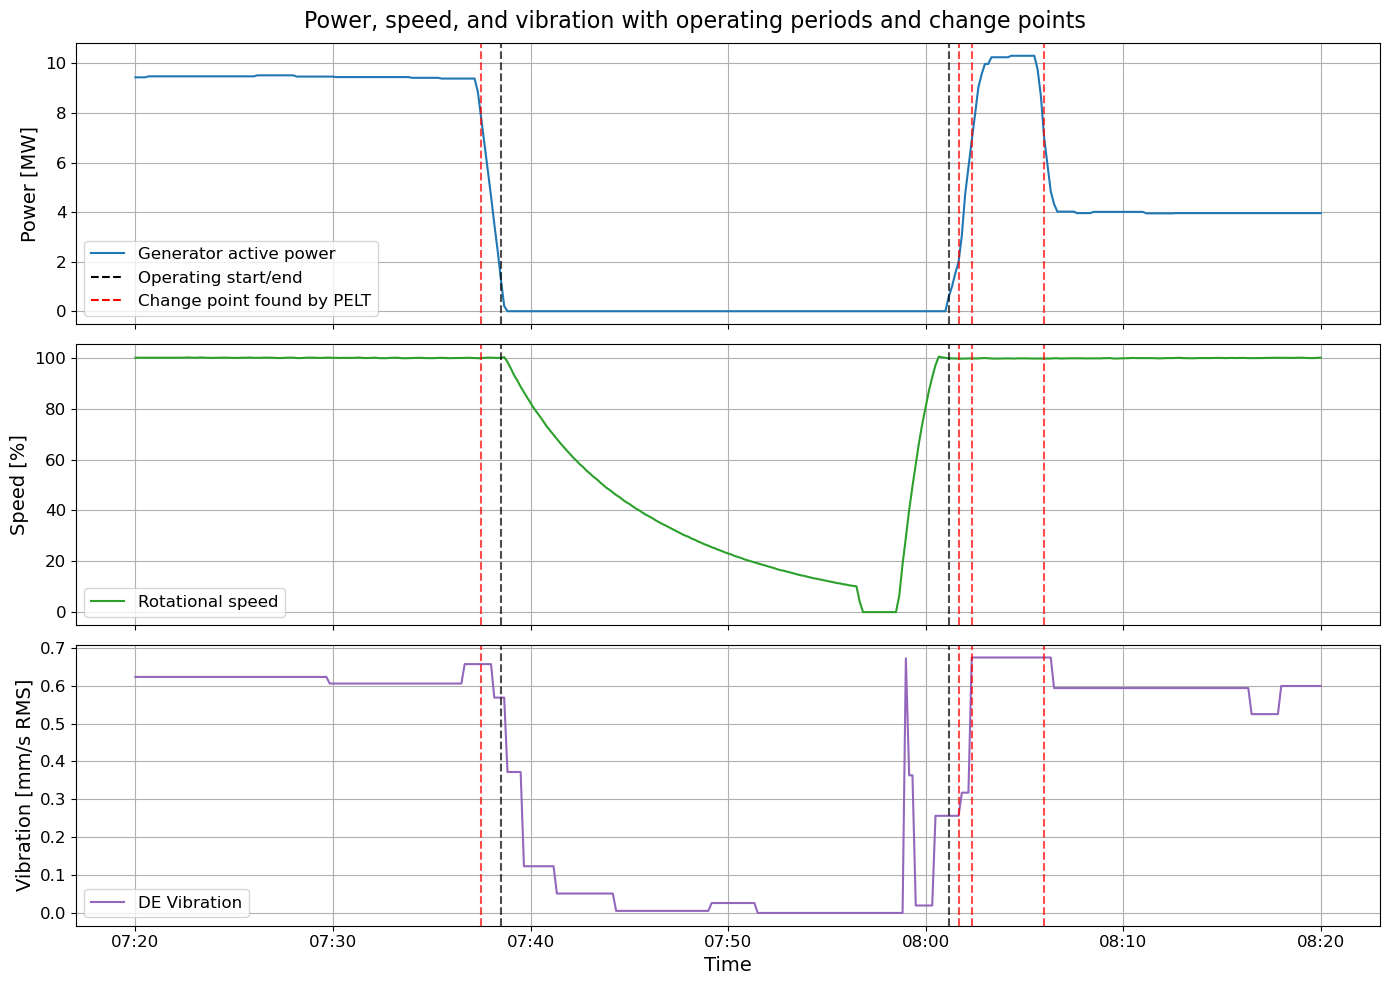

In [6]:
plot_start = pd.Timestamp("2024-06-03 07:20:00")
plot_end = plot_start + pd.Timedelta(hours=1)

speed_name = "Rotational speed"

speed = dfs.loc[
    dfs["name"] == speed_name,
    "signal_df"
].iloc[0]

power_plot = power[power["Datetime"].between(plot_start, plot_end)]
speed_plot = speed[speed["Datetime"].between(plot_start, plot_end)]
vib_plot = vib[vib["Datetime"].between(plot_start, plot_end)]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(
    power_plot["Datetime"],
    power_plot["signal"],
    label=power_name,
    color="tab:blue"
)

axes[1].plot(
    speed_plot["Datetime"],
    speed_plot["signal"],
    label=speed_name,
    color="tab:green"
)

axes[2].plot(
    vib_plot["Datetime"],
    vib_plot["signal"],
    label=vib_name,
    color="tab:purple"
)

axes[0].set_ylabel("Power [MW]", fontsize=14)
axes[1].set_ylabel("Speed [%]", fontsize=14)
axes[2].set_ylabel("Vibration [mm/s RMS]", fontsize=14)
axes[2].set_xlabel("Time", fontsize=14)

for _, period in operating_periods.iterrows():
    for t in [period["start_time"], period["end_time"]]:
        if plot_start <= t <= plot_end:
            for ax in axes:
                ax.axvline(t, color="black", linestyle="--", alpha=0.7)

for t in pelt_times:
    if plot_start <= t <= plot_end:
        for ax in axes:
            ax.axvline(t, color="red", linestyle="--", alpha=0.7)

axes[0].plot([], [], color="black", linestyle="--", label="Operating start/end")
axes[0].plot([], [], color="red", linestyle="--", label="Change point found by PELT")

for ax in axes:
    ax.grid(True)
    ax.legend(fontsize=12, loc="lower left")
    ax.tick_params(axis="both", labelsize=12)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.suptitle(
    "Power, speed, and vibration with operating periods and change points",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "power_speed_vibration_pelt_breakpoints.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
windows = make_window_features(
    ref_df=power,
    operating_periods=operating_periods,
    window_size=6,
    n_periods=20,
)

windows.sort_values(by="std_power", ascending=False).head()


,operating_period,start_time,end_time,mean_power,std_power,start_idx,end_idx
25220,9,2024-06-19 06:45:20,2024-06-19 06:46:10,6.935000,2.045301,3294,3299
19315,7,2024-06-15 02:58:50,2024-06-15 02:59:40,7.436666,1.959368,47544,47549
20901,7,2024-06-16 05:24:50,2024-06-16 05:25:40,3.831667,1.938895,57060,57065
3541,2,2024-06-03 12:42:10,2024-06-03 12:43:00,6.725000,1.841609,1686,1691
15859,7,2024-06-12 17:22:50,2024-06-12 17:23:40,7.428333,1.835515,26808,26813


In [8]:
eps_results = test_dbscan_eps(
    windows,
    eps_start=0.05,
    eps_stop=0.30,
    eps_step=0.02,
    min_samples=5
)

eps_results

,epsilon,n_clusters,noise_percent
0,0.05,56,1.169054
1,0.07,12,0.799984
2,0.09,7,0.658341
3,0.11,3,0.608467
4,0.13,4,0.502733
5,0.15,7,0.446874
6,0.17,10,0.383035
7,0.19,10,0.341140
8,0.21,6,0.307226
9,0.23,2,0.283286


In [9]:
clustered_windows, steady_intervals = extract_steady_states_from_windows(
    windows,
    eps=0.11,
    min_samples=5
)

In [10]:
summary = (
    clustered_windows
    .groupby("cluster")
    .agg(
        n_windows=("cluster", "size"),
        mean_power=("mean_power", "mean"),
        mean_std_power=("std_power", "mean"),
        min_power=("mean_power", "min"),
        max_power=("mean_power", "max")
    )
    .sort_index()
)

summary

,n_windows,mean_power,mean_std_power,min_power,max_power
cluster,,,,,
-1,305,5.296497,0.330812,0.636667,10.266666
0,49810,6.178946,0.003821,0.500000,10.410000
1,6,9.973611,0.068618,9.755000,10.170000
2,5,1.610667,0.062257,1.380000,1.755000


In [11]:
base_colors = [
    "tab:green",
    "tab:orange",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan"
]

clusters = sorted(clustered_windows["cluster"].dropna().unique())

cluster_colors = {-1: "tab:blue"}  # DBSCAN outliers

normal_clusters = [cluster for cluster in clusters if cluster != -1]

for i, cluster in enumerate(normal_clusters):
    cluster_colors[cluster] = base_colors[i % len(base_colors)]

outlier_handle = mpatches.Patch(
    color=cluster_colors[-1],
    label="Outliers"
)

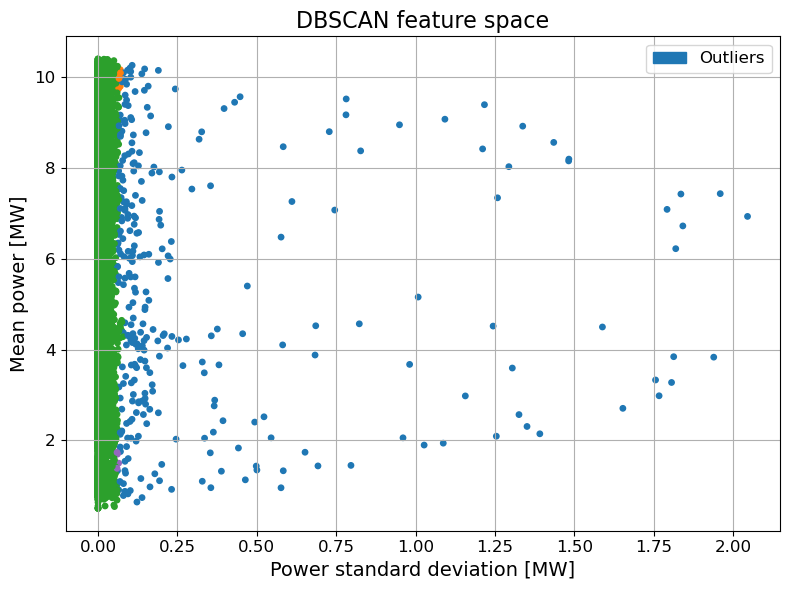

In [12]:
point_colors = clustered_windows["cluster"].map(cluster_colors)

plt.figure(figsize=(8, 6))

plt.scatter(
    clustered_windows["std_power"],
    clustered_windows["mean_power"],
    c=point_colors,
    s=15
)

plt.legend(handles=[outlier_handle], fontsize=12, loc="upper right")

plt.xlabel("Power standard deviation [MW]", fontsize=14)
plt.ylabel("Mean power [MW]", fontsize=14)
plt.title("DBSCAN feature space", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True)
plt.tight_layout()

plt.savefig("dbscan_feature_space.png", dpi=300, bbox_inches="tight")

plt.show()

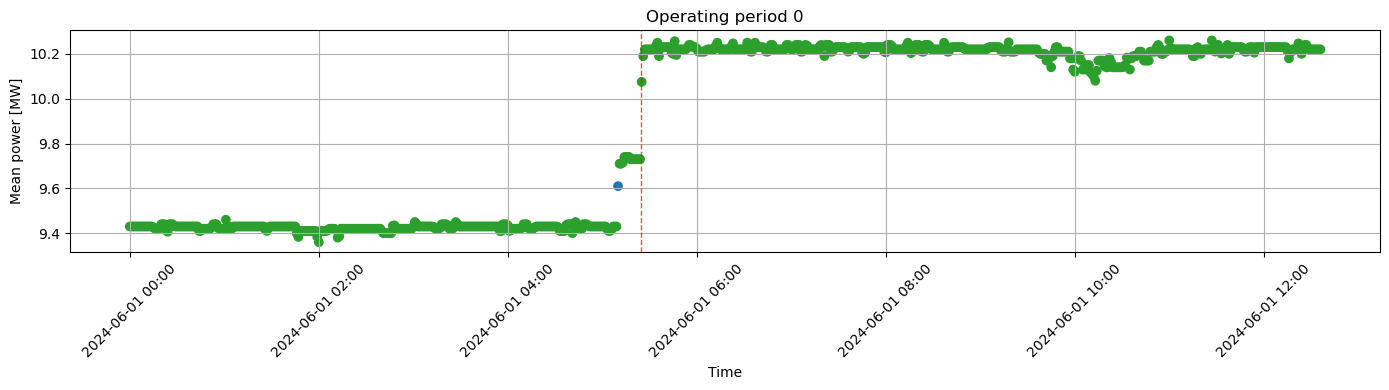

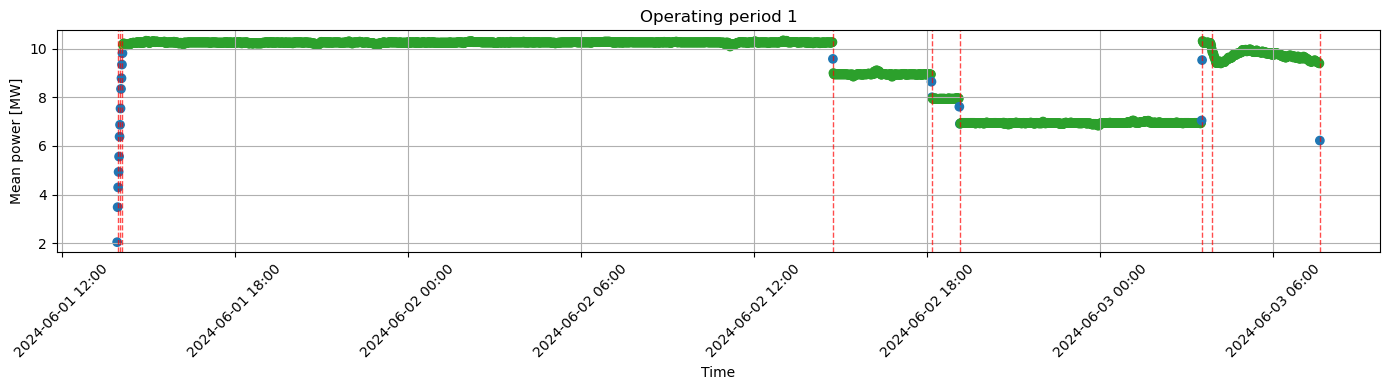

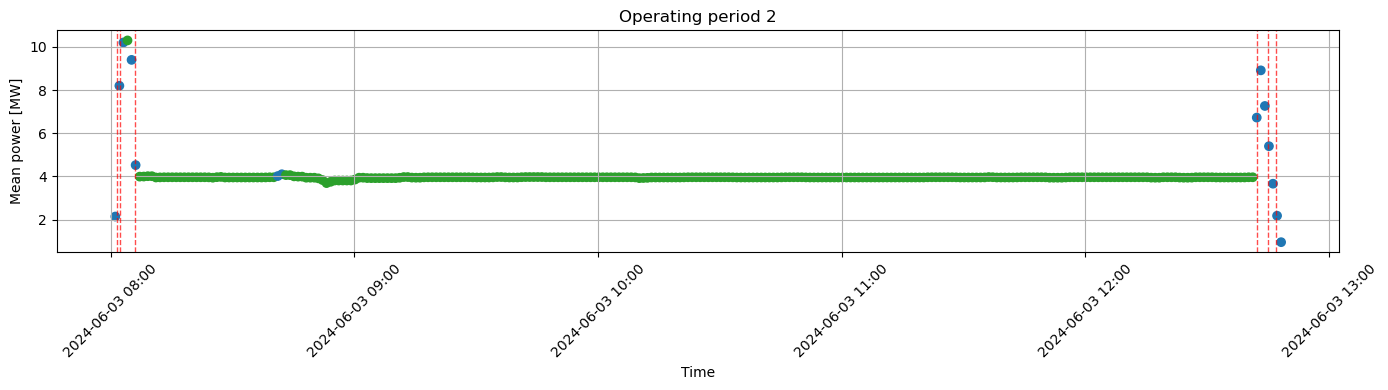

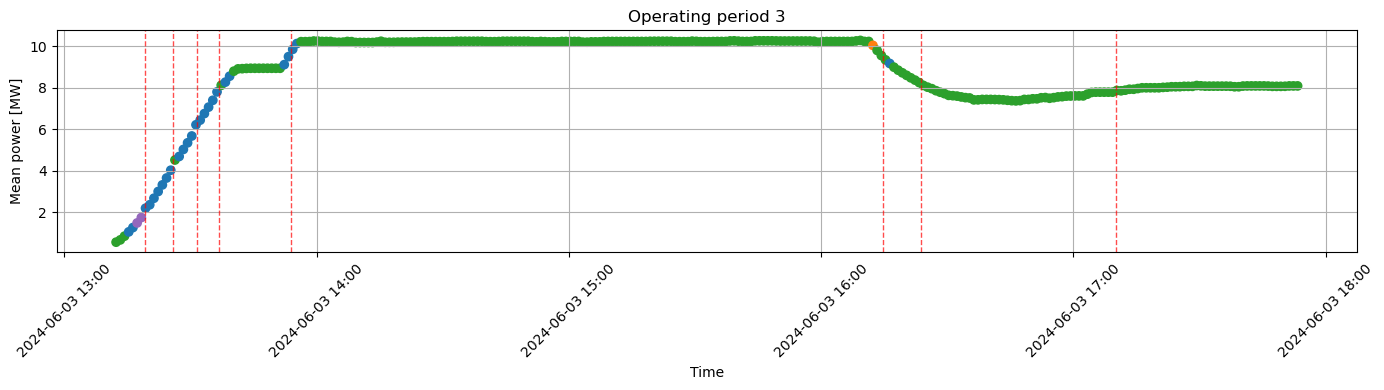

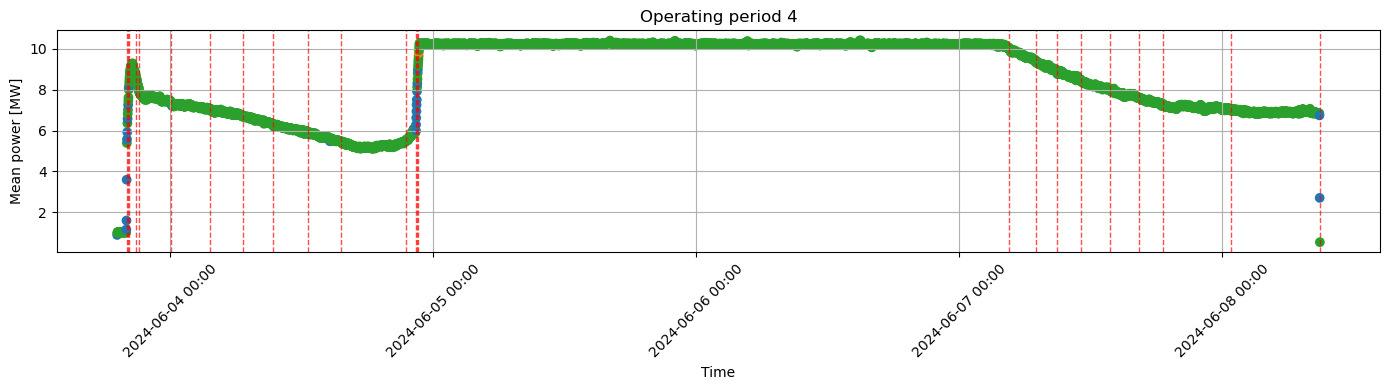

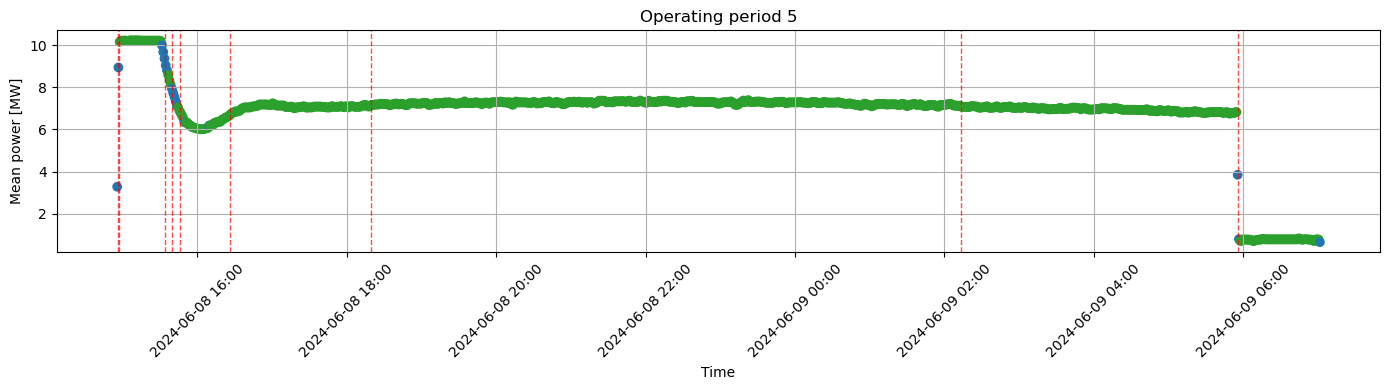

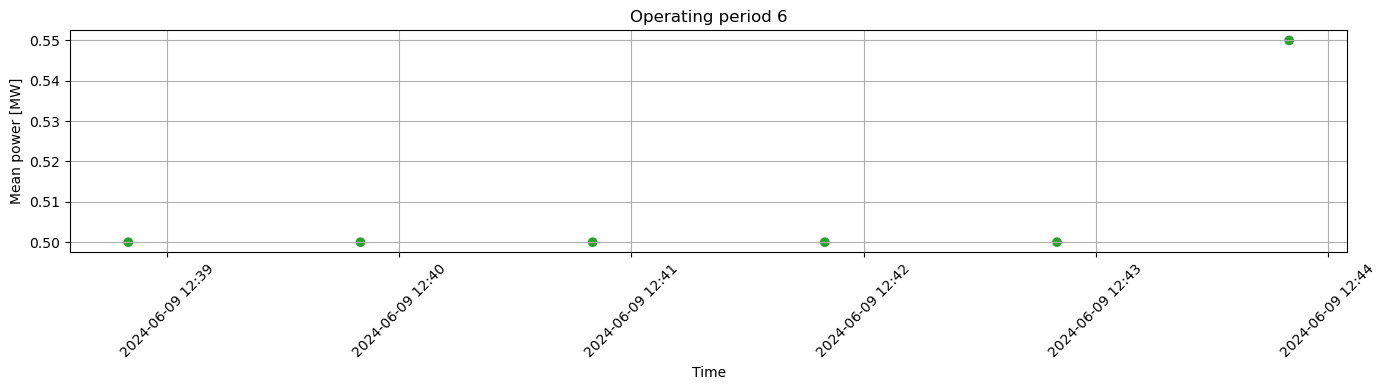

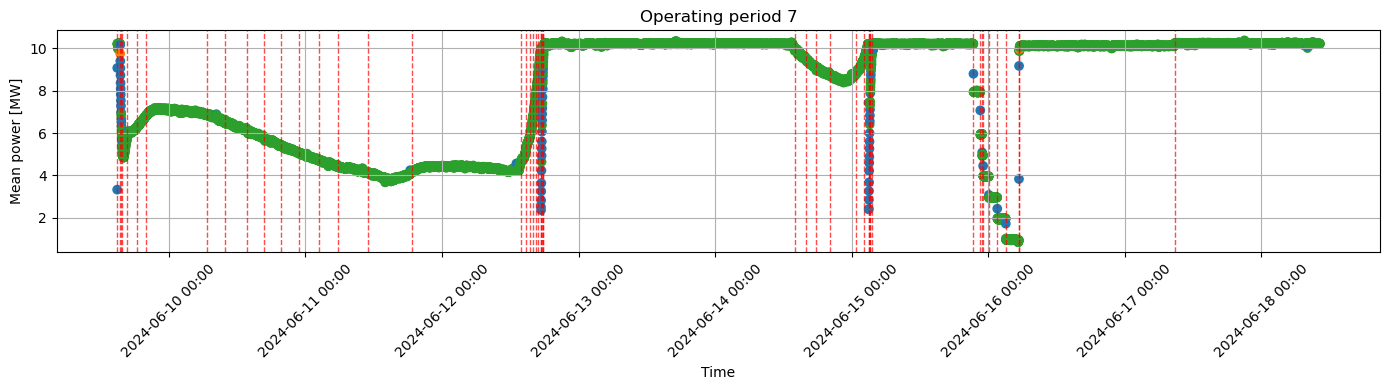

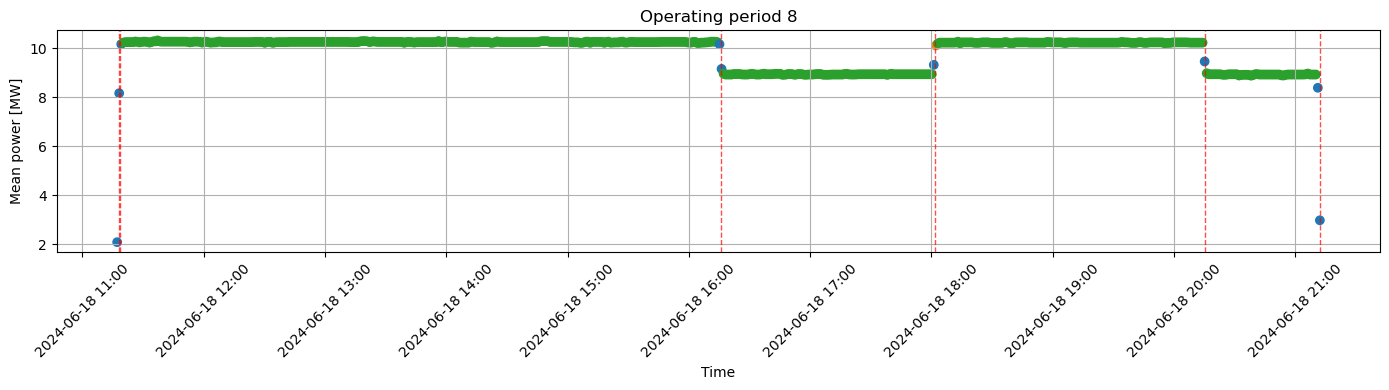

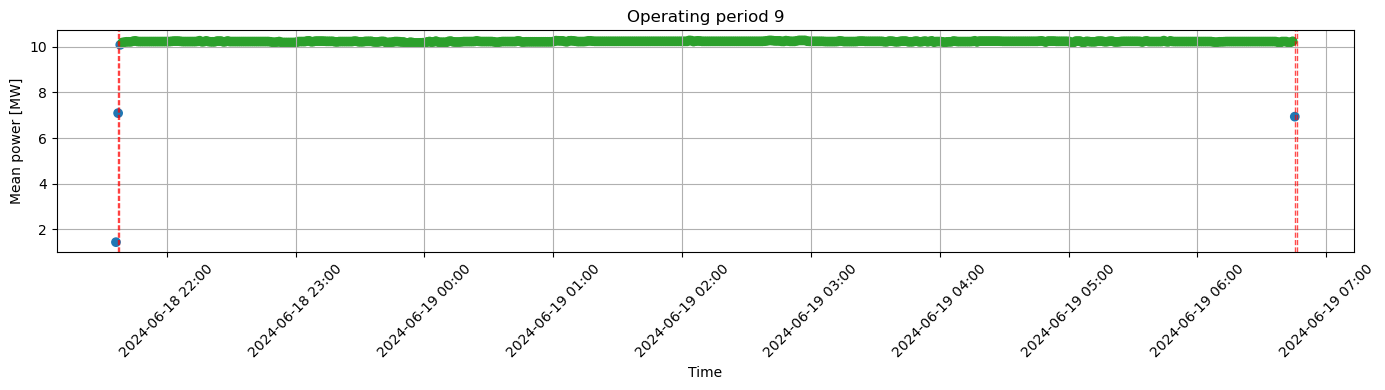

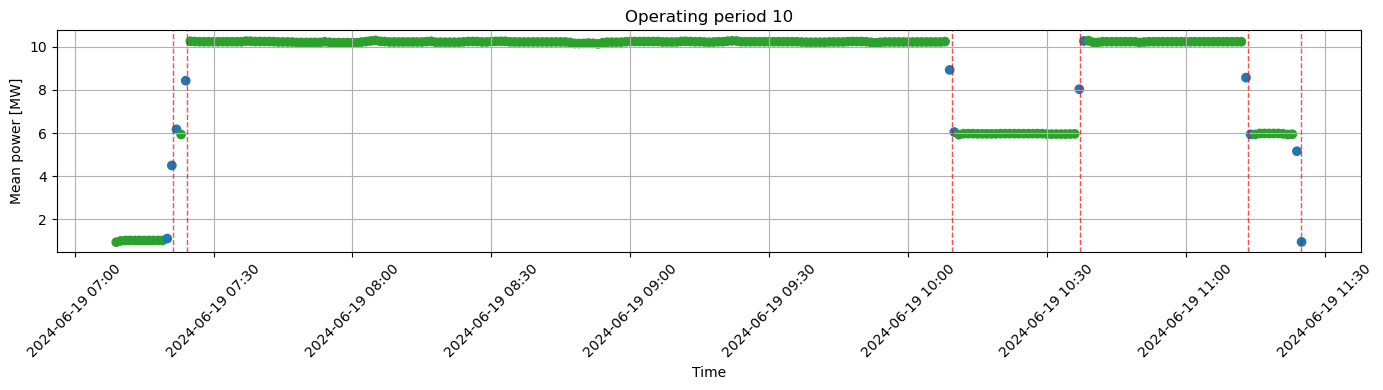

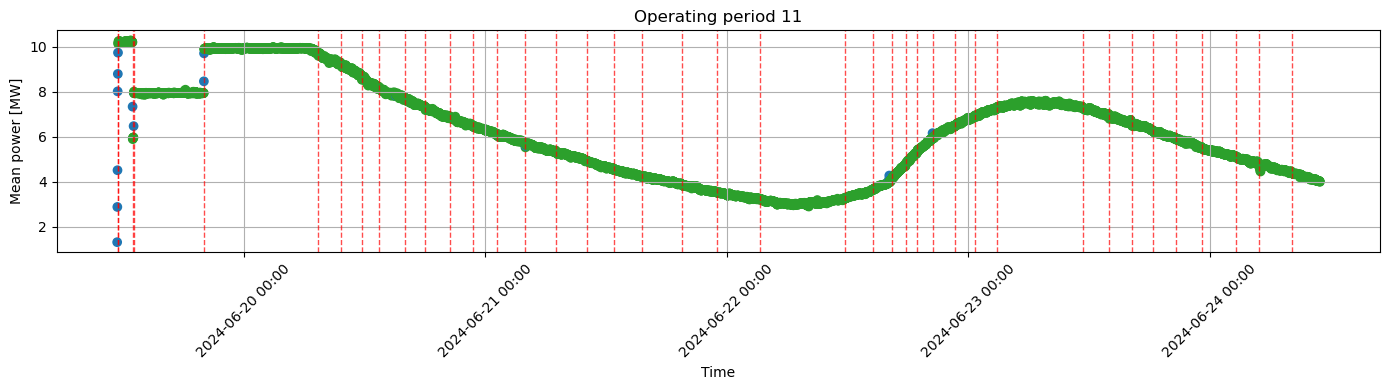

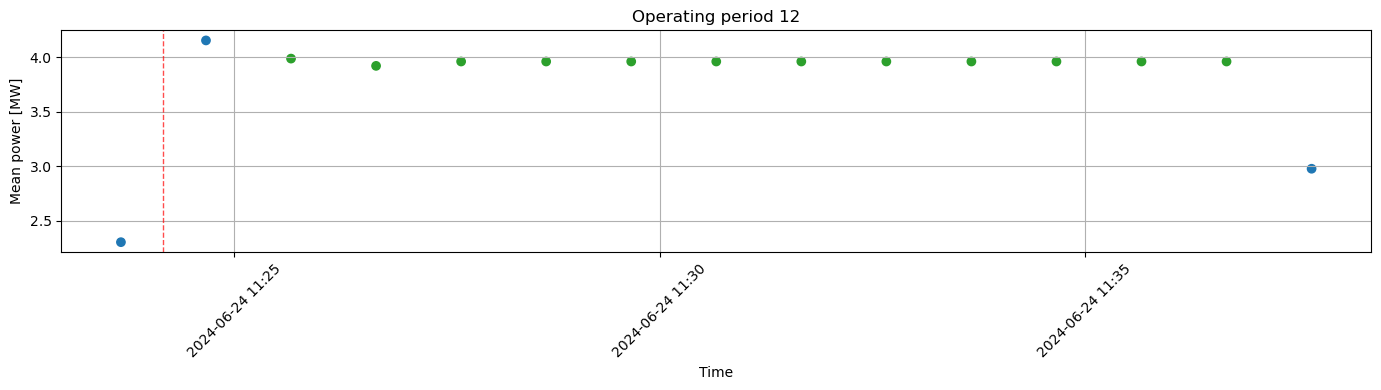

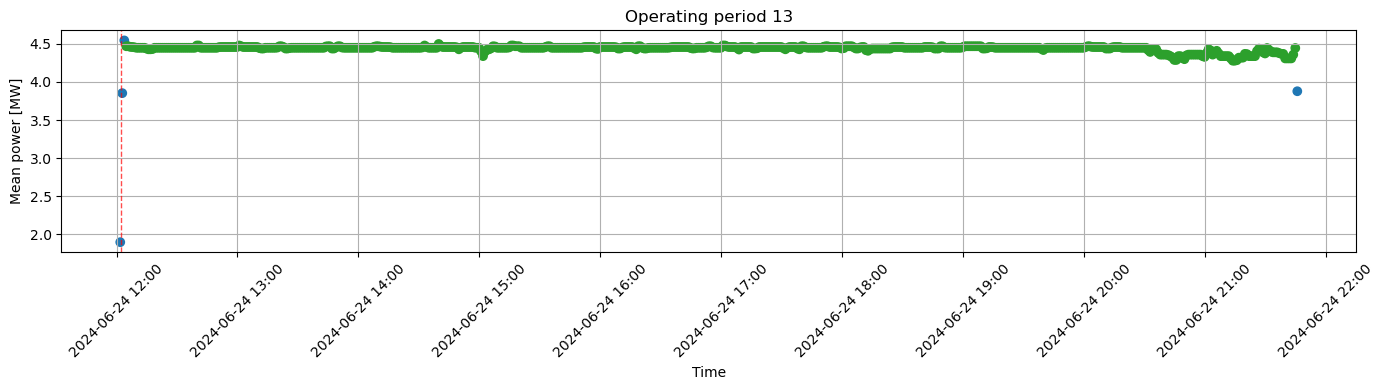

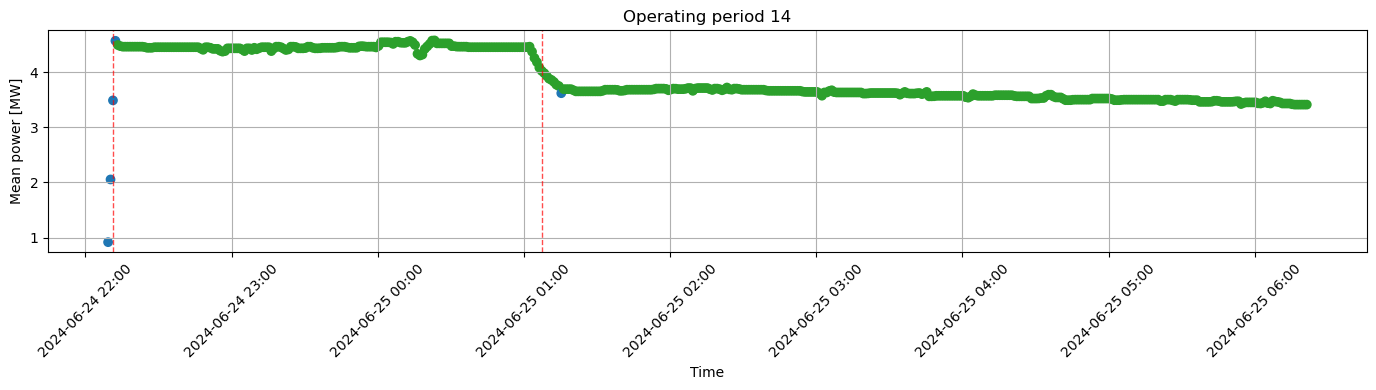

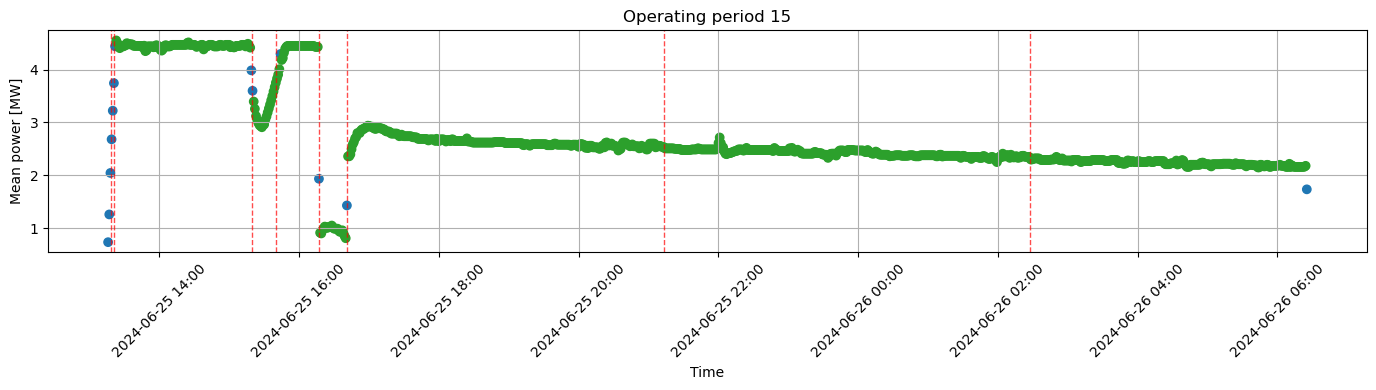

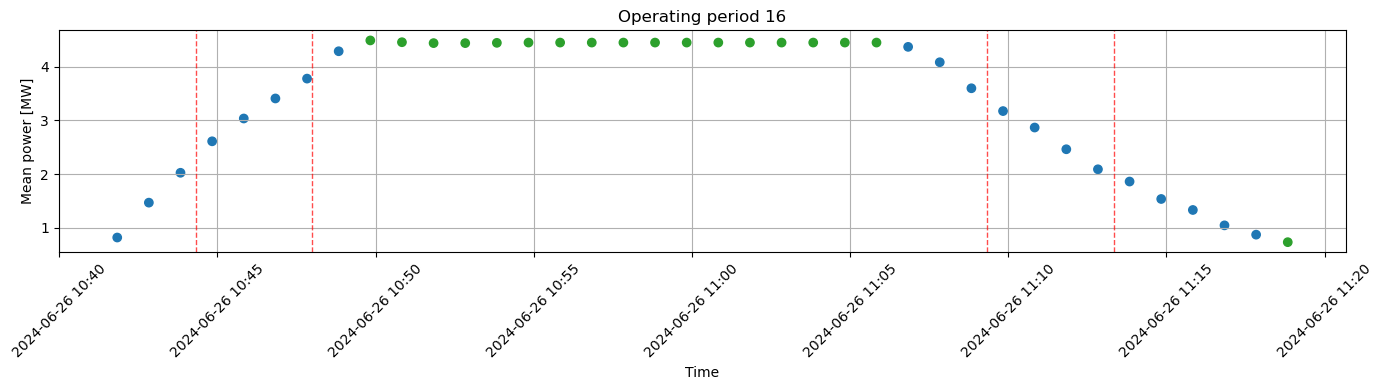

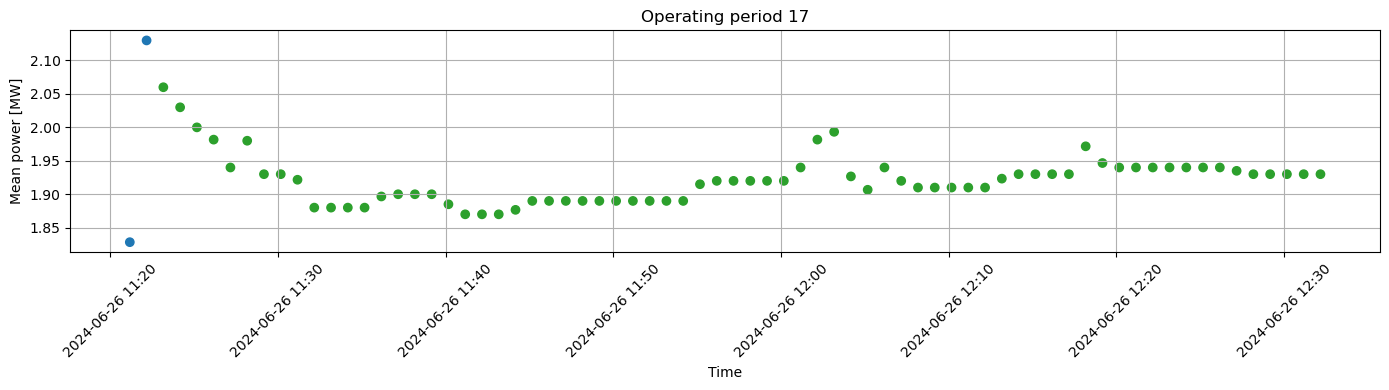

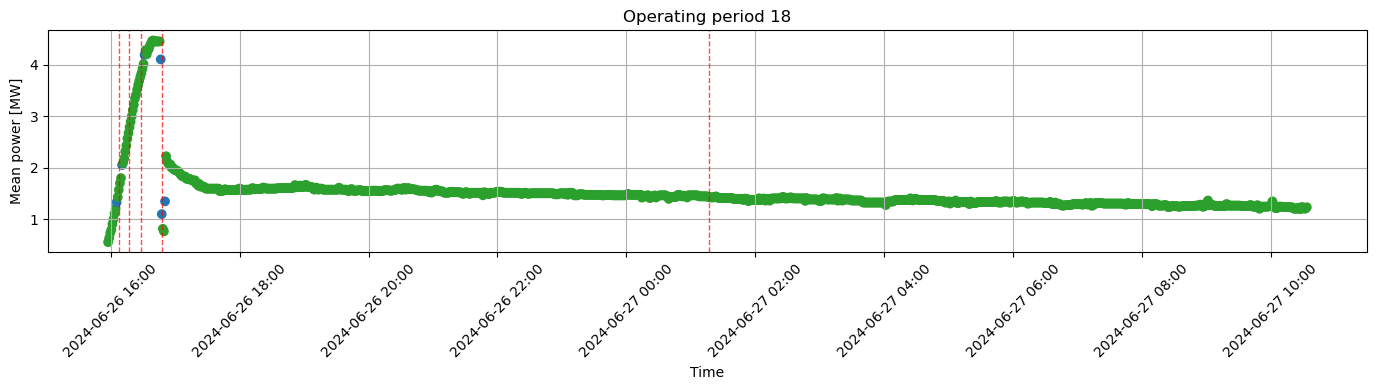

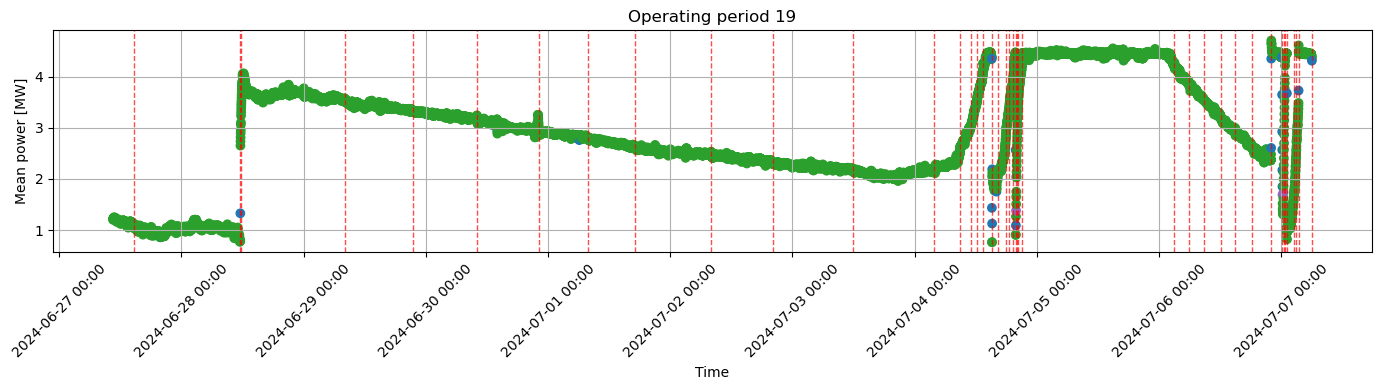

In [13]:
for operating_period in sorted(clustered_windows["operating_period"].unique()):
    period_windows = clustered_windows[
        clustered_windows["operating_period"] == operating_period
    ]

    period_start = period_windows["start_time"].min()
    period_end = period_windows["end_time"].max()

    point_colors = period_windows["cluster"].map(cluster_colors)

    plt.figure(figsize=(14, 4))

    plt.scatter(
        period_windows["start_time"],
        period_windows["mean_power"],
        c=point_colors
    )

    for change_time in pelt_times:
        if period_start <= change_time <= period_end:
            plt.axvline(
                change_time,
                color="red",
                linestyle="--",
                linewidth=1,
                alpha=0.7
            )

    plt.xlabel("Time")
    plt.ylabel("Mean power [MW]")
    plt.title(f"Operating period {operating_period}")
    plt.grid(True)

    plt.gca().xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m-%d %H:%M")
    )
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

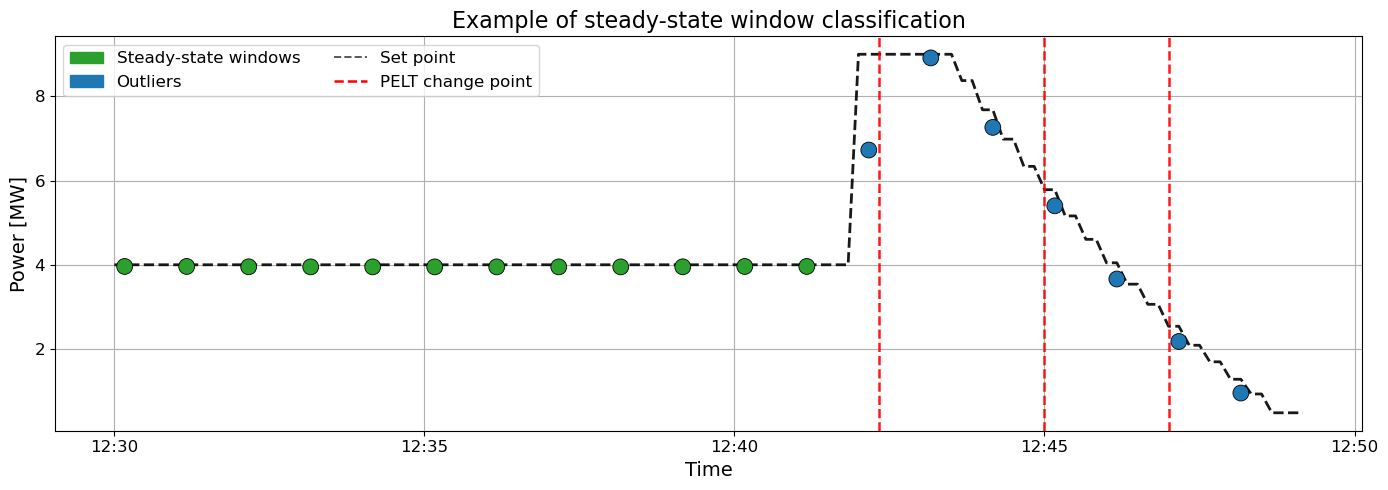

In [14]:
operating_period = 2

period = operating_periods.loc[operating_period]

start_time = pd.Timestamp("2024-06-03 12:30:00")
end_time = period["end_time"]

plot_windows = clustered_windows[
    (clustered_windows["operating_period"] == operating_period) &
    (clustered_windows["start_time"] >= start_time) &
    (clustered_windows["start_time"] <= end_time)
].copy()

plot_setpoint = setpoint[
    (setpoint["Datetime"] >= start_time) &
    (setpoint["Datetime"] <= end_time)
].copy()

point_colors = plot_windows["cluster"].map(cluster_colors)

steady_handle = mpatches.Patch(
    color="tab:green",
    label="Steady-state windows"
)

outlier_handle = mpatches.Patch(
    color=cluster_colors[-1],
    label="Outliers"
)

setpoint_handle = plt.Line2D(
    [],
    [],
    color="black",
    linestyle="--",
    linewidth=1.4,
    alpha=0.65,
    label="Set point"
)

pelt_handle = plt.Line2D(
    [],
    [],
    color="red",
    linestyle="--",
    linewidth=1.8,
    label="PELT change point"
)

plt.figure(figsize=(14, 5))

plt.plot(
    plot_setpoint["Datetime"],
    plot_setpoint["signal"],
    color="black",
    linestyle="--",
    linewidth=2.0,
    alpha=0.9,
    zorder=2
)

plt.scatter(
    plot_windows["start_time"],
    plot_windows["mean_power"],
    c=point_colors,
    s=130,
    edgecolors="black",
    linewidths=0.6,
    zorder=3
)

for change_time in pelt_times:
    if start_time <= change_time <= end_time:
        plt.axvline(
            change_time,
            color="red",
            linestyle="--",
            linewidth=1.8,
            alpha=0.9,
            zorder=5
        )

plt.xlabel("Time", fontsize=14)
plt.ylabel("Power [MW]", fontsize=14)
plt.title(
    "Example of steady-state window classification",
    fontsize=16
)

plt.grid(True)
plt.tick_params(axis="both", labelsize=12)

plt.legend(
    handles=[
        steady_handle,
        outlier_handle,
        setpoint_handle,
        pelt_handle
    ],
    fontsize=12,
    loc="upper left",
    ncol=2,
    frameon=True
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()

plt.savefig(
    f"operating_period_{operating_period}_steady_state_windows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
WINDOW_SIZE = 6

windows_all = make_window_features(
    ref_df=power,
    operating_periods=operating_periods,
    window_size=WINDOW_SIZE,
)

windows_all.head()


,operating_period,start_time,end_time,mean_power,std_power,start_idx,end_idx
0,0,2024-06-01 00:00:00,2024-06-01 00:00:50,9.429999,0.0,0,5
1,0,2024-06-01 00:01:00,2024-06-01 00:01:50,9.429999,0.0,6,11
2,0,2024-06-01 00:02:00,2024-06-01 00:02:50,9.429999,0.0,12,17
3,0,2024-06-01 00:03:00,2024-06-01 00:03:50,9.429999,0.0,18,23
4,0,2024-06-01 00:04:00,2024-06-01 00:04:50,9.429999,0.0,24,29


In [16]:
STD_THRESHOLD = windows_all["std_power"].quantile(0.99)
windows_threshold, steady_intervals_all = extract_steady_states_by_threshold(
    windows_all,
    std_threshold=STD_THRESHOLD
)

windows_threshold.head()


,operating_period,start_time,end_time,mean_power,std_power,start_idx,end_idx,is_steady,interval_id
0,0,2024-06-01 00:00:00,2024-06-01 00:00:50,9.429999,0.0,0,5,True,1
1,0,2024-06-01 00:01:00,2024-06-01 00:01:50,9.429999,0.0,6,11,True,1
2,0,2024-06-01 00:02:00,2024-06-01 00:02:50,9.429999,0.0,12,17,True,1
3,0,2024-06-01 00:03:00,2024-06-01 00:03:50,9.429999,0.0,18,23,True,1
4,0,2024-06-01 00:04:00,2024-06-01 00:04:50,9.429999,0.0,24,29,True,1


In [17]:
print("Window size [samples]:", WINDOW_SIZE)
print("Std threshold [MW]:", STD_THRESHOLD)
print("Operating periods with windows:", windows_all["operating_period"].nunique())
print("Total operating periods:", len(operating_periods))
print("All windows:", len(windows_threshold))
print("Steady windows:", windows_threshold["is_steady"].sum())
print("Steady windows [%]:", round(windows_threshold["is_steady"].mean() * 100, 2))
print("Steady intervals:", len(steady_intervals_all))


Window size [samples]: 6
Std threshold [MW]: 0.04999995231628418
Operating periods with windows: 59
Total operating periods: 59
All windows: 212374
Steady windows: 210305
Steady windows [%]: 99.03
Steady intervals: 956


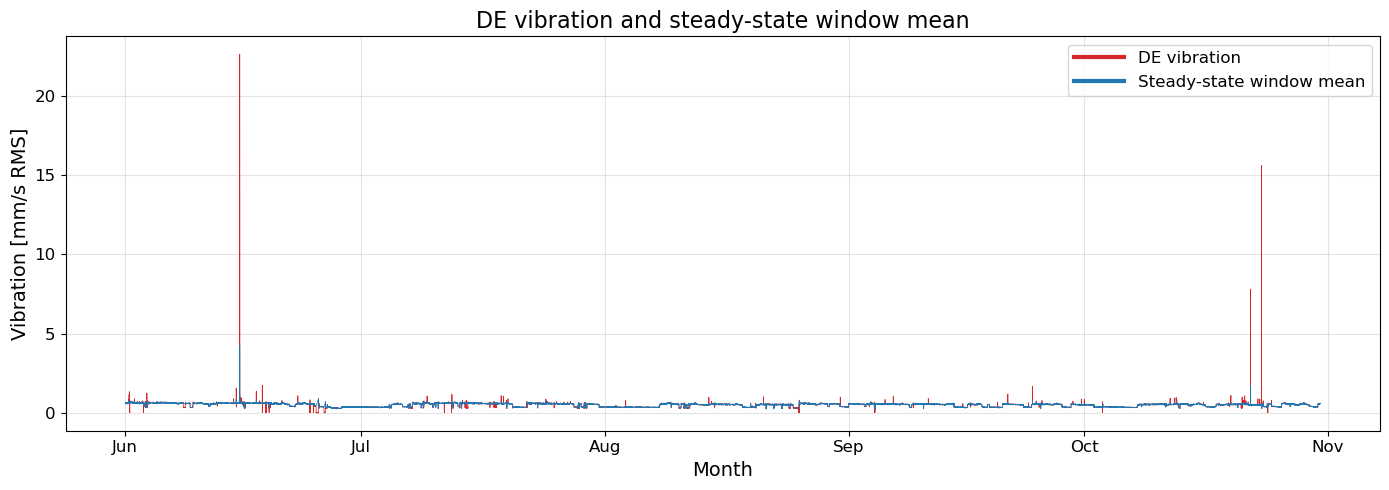

In [18]:
vib_color = "tab:red"
mean_color = "tab:blue"

vib_df = dfs.loc[
    dfs["name"] == "DE Vibration",
    "signal_df"
].iloc[0].copy()

vib_df = (
    vib_df
    .dropna(subset=["Datetime", "signal"])
    .sort_values("Datetime")
)

steady_windows = windows_threshold[
    windows_threshold["is_steady"]
].copy()

steady_windows["mid_time"] = (
    steady_windows["start_time"] +
    (steady_windows["end_time"] - steady_windows["start_time"]) / 2
)

steady_windows["mean_vibration"] = _window_mean(vib_df, steady_windows)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    vib_df["Datetime"],
    vib_df["signal"],
    linewidth=0.55,
    color=vib_color,
    label="DE vibration"
)

ax.plot(
    steady_windows["mid_time"],
    steady_windows["mean_vibration"],
    linewidth=0.55,
    color=mean_color,
    label="Steady-state window mean"
)

ax.set_title("DE vibration and steady-state window mean", fontsize=16)
ax.set_xlabel("Month", fontsize=14)
ax.set_ylabel("Vibration [mm/s RMS]", fontsize=14)

ax.grid(True, alpha=0.35)

legend_handles = [
    Line2D([0], [0], color=vib_color, linewidth=3.0, label="DE vibration"),
    Line2D([0], [0], color=mean_color, linewidth=3.0, label="Steady-state window mean")
]

ax.legend(
    handles=legend_handles,
    fontsize=12,
    loc="upper right",
    frameon=True,
    handlelength=3.0
)

ax.tick_params(axis="both", labelsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()

plt.savefig(
    "vibration_steady_window_mean_full.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
model_1min = build_model_window_df(
    windows_threshold,
    pos=pos,
    field_current=field_current,
    inletp=inletp,
    vib=vib,
)

In [21]:
model_1min.to_csv("steady_state_model_dataset_1min.csv", index=False)